# Part III — Model Optimization


Model optimization is the process of improving a machine learning model's performance by tuning its hyperparameters and preprocessing the data. The goal is to reduce loss, achieve faster convergence, and build a model that generalizes well on unseen data.


## Why Model Optimization?

- **Reduce Loss** — Part II model had high loss (927) and did not converge
- **Faster Convergence** — Proper scaling and learning rate help the model reach minimum quickly
- **Better Accuracy** — Optimized model fits the data more closely
- **Avoid Overfitting/Underfitting** — Right balance between bias and variance
- **Reproducible Results** — Consistent performance across runs



## What We'll Cover in Part III

| Step | Topic | Purpose |
|------|-------|---------|
| 1 | Setup — Load Part II Data | Same fake dataset |
| 2 | Diagnose Part II Problem | Why loss = 927 |
| 3 | Feature Scaling (From Scratch) | Normalize X and Y |
| 4 | Learning Rate Comparison | Test α = 0.001 to 0.5 |
| 5 | Epochs Comparison | Test 10 to 1000 |
| 6 | Convergence Detection | Auto-stop when loss stops changing |
| 7 | Final Optimized Model | Best α + best epochs |
| 8 | Before vs After Comparison | Part II vs Part III |
| 9 | R² Score (From Scratch) | Model validation |
| 10 | Residual Analysis | Check model assumptions |




**Let's begin by diagnosing why Part II model did not converge.**

#### Step by step Impletation.
##### step 1 : Load fake dataset same to we used in part II

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

data={
    "X":[1,2,3,4,5,6,7,8],
    "Y":[89,74,67,80,89,70,69,79]
}
df=pd.DataFrame(data)
X=df["X"].values
Y=df["Y"].values
df

,X,Y
0,1,89
1,2,74
2,3,67
3,4,80
4,5,89
5,6,70
6,7,69
7,8,79


### Step 2: Training Loop 

In [4]:
m, b = 0, 0
lr = 0.01
loss_history = []

for i in range(50):
    y_pred = m * X + b
    error = y_pred - Y
    loss = (error**2).mean()
    loss_history.append(loss)
    n = len(df)
    dm = (2/n) * np.sum(error * X)
    db = (2/n) * np.sum(error)
    m -= lr * dm
    b -= lr * db

print(f"Final m: {m:.4f}")
print(f"Final b: {b:.4f}")
print(f"First loss: {loss_history[0]:.2f}")
print(f"Last loss: {loss_history[-1]:.2f}")
print(f"Loss still decreasing? {loss_history[-1] < loss_history[-2]}")
print(f"Problem Loss not converged still {loss_history[-1]:.2f}")

Final m: 10.5751
Final b: 16.6397
First loss: 6013.62
Last loss: 927.51
Loss still decreasing? True
Problem Loss not converged still 927.51


### Stpe 3: Feature Scaling (Mini-max Scaling)

In [6]:
X_min = X.min()
X_max = X.max()
Y_min = Y.min()
Y_max = Y.max()

X_scaled = (X - X_min) / (X_max - X_min)
Y_scaled = (Y - Y_min) / (Y_max - Y_min)

print("X Min:", X_min, "| X Max:", X_max)
print("Y Min:", Y_min, "| Y Max:", Y_max)
print("\nX Scaled:", np.round(X_scaled, 2))
print("Y Scaled:", np.round(Y_scaled, 2))

X Min: 1 | X Max: 8
Y Min: 67 | Y Max: 89

X Scaled: [0.   0.14 0.29 0.43 0.57 0.71 0.86 1.  ]
Y Scaled: [1.   0.32 0.   0.59 1.   0.14 0.09 0.55]


### Step 4:  Learning Rate Comparison

Learning rate comparison is the process of testing different learning rate values (lr) to find the one that gives fastest convergence and lowest loss.


In [ ]:
lrs = [0.001, 0.01, 0.05, 0.1, 0.5]
results = {}

for lr in lrs:
    mt, bt = 0, 0
    loss_hist = []

    for i in range(500):
        y_pred = mt * X_scaled + bt
        error = y_pred - Y_scaled
        loss = (error**2).mean()
        loss_hist.append(loss)

        n = len(df)
        dm = (2/n) * np.sum(error * X_scaled)
        db = (2/n) * np.sum(error)
        mt -= lr * dm
        bt -= lr * db

    results[lr] = loss_hist


### step 5: Ploting All

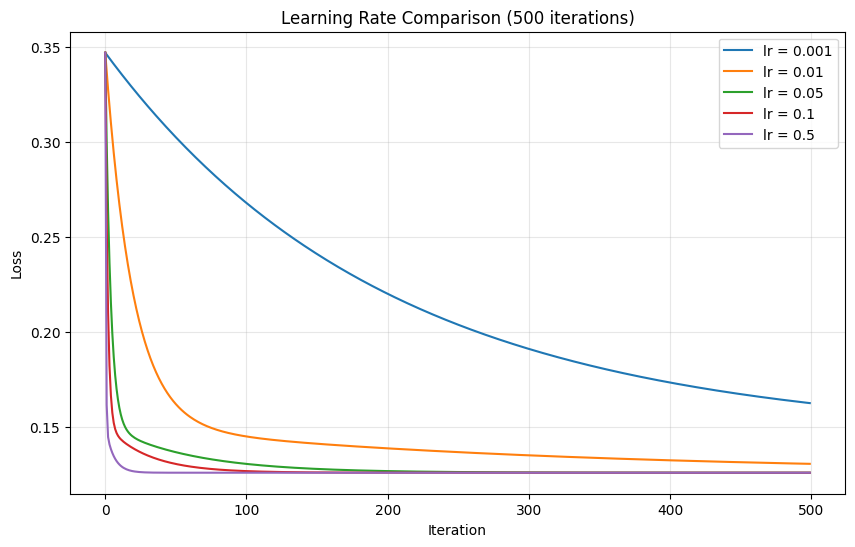


Final Loss for each LR:
  lr = 0.001: 0.162547
  lr = 0.01: 0.130602
  lr = 0.05: 0.125931
  lr = 0.1: 0.125925
  lr = 0.5: 0.125925


In [8]:
plt.figure(figsize=(10, 6))
for lr_test, hist in results.items():
    plt.plot(hist, label=f"lr = {lr_test}")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Learning Rate Comparison (500 iterations)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\nFinal Loss for each LR:")
for lr_test, hist in results.items():
    print(f"  lr = {lr_test}: {hist[-1]:.6f}")

### Step 6: Epch comprision

In [ ]:
epochs_list = [10, 50, 100, 500, 1000]
best_lr = 0.1
loss_results = {}

for ep in epochs_list:
    m_t, b_t = 0, 0
    loss_hist = []

    for i in range(ep):
        y_pred = m_t * X_scaled + b_t
        error = y_pred - Y_scaled
        loss = (error**2).mean()
        loss_hist.append(loss)

        n = len(df)
        dm = (2/n) * np.sum(error * X_scaled)
        db = (2/n) * np.sum(error)
        m_t -= best_lr * dm
        b_t -= best_lr * db

    loss_results[ep] = loss_hist[-1]
    print(f"Epochs = {ep:4d}, Final Loss = {loss_hist[-1]:.6f}")


Epochs =   10, Final Loss = 0.145427
Epochs =   50, Final Loss = 0.130686
Epochs =  100, Final Loss = 0.126797
Epochs =  500, Final Loss = 0.125925
Epochs = 1000, Final Loss = 0.125925


### Step 6: Ploting 

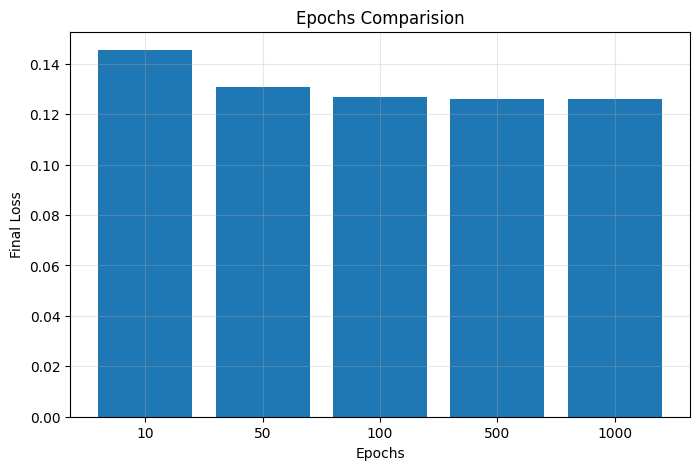

In [11]:
plt.figure(figsize=(8, 5))
plt.bar([str(e) for e in epochs_list], list(loss_results.values()))
plt.xlabel("Epochs")
plt.ylabel("Final Loss")
plt.title("Epochs Comparision")
plt.grid(True, alpha=0.3)
plt.show()